PASO 1: Generando datos sintéticos
Datos generados: 300 muestras con 2 características
Centros reales de los datos: 3 clusters

PASO 2: Visualizando datos originales


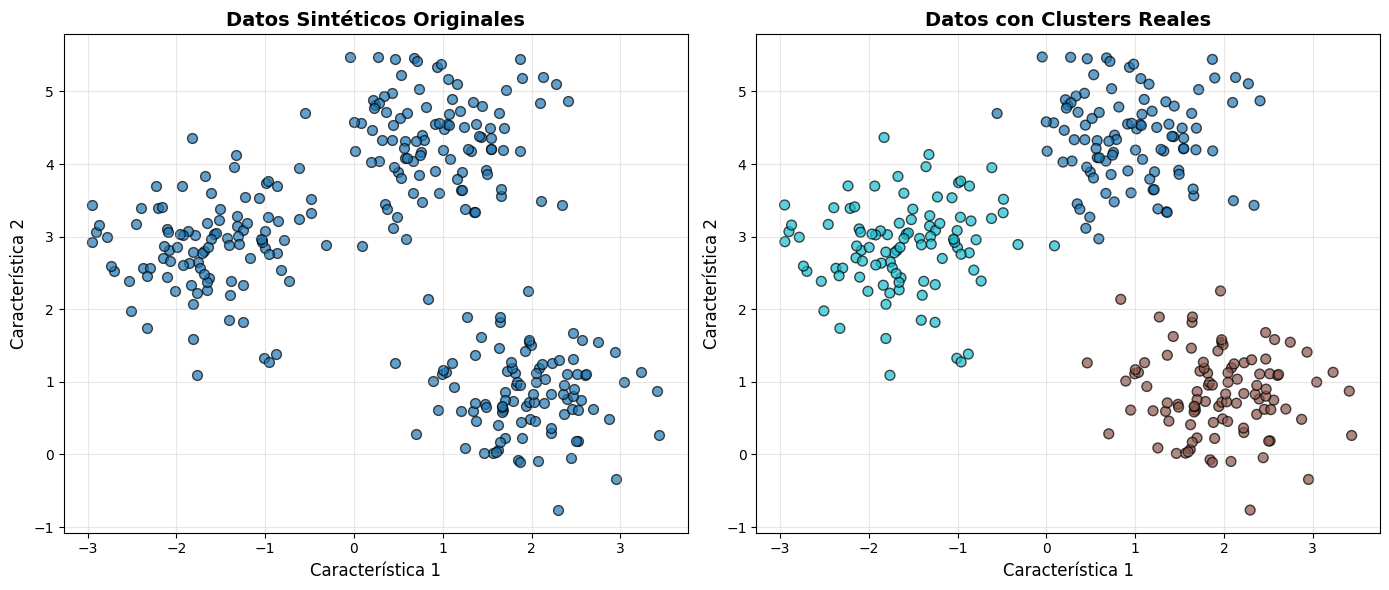

PASO 3: Aplicando algoritmo K-Means
Modelo K-Means entrenado exitosamente
Número de iteraciones realizadas: 3
Centros de los clusters encontrados:
  Cluster 0: [-1.61, 2.86]
  Cluster 1: [1.95, 0.83]
  Cluster 2: [0.96, 4.37]

PASO 4: Visualizando resultados


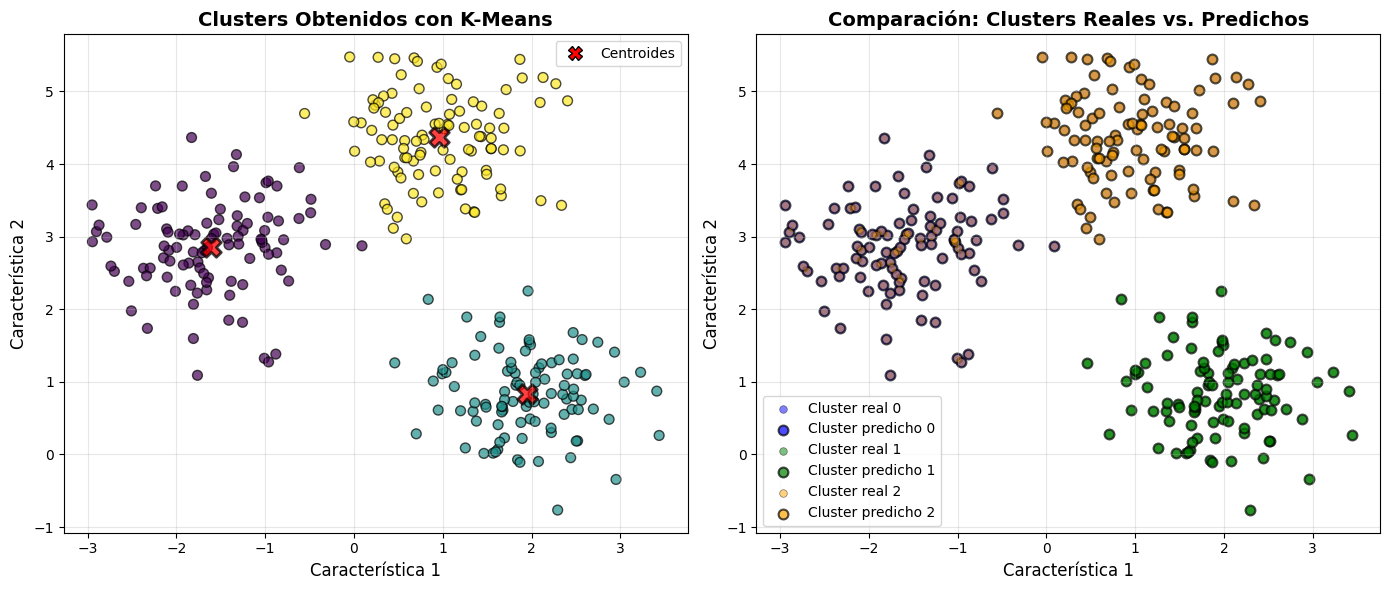

PASO 5: Análisis de resultados
Métricas de evaluación:
  - Coeficiente de silueta: 0.6596
     (Valor cercano a 1 indica buenos clusters)
  - Índice Rand ajustado: 1.0000
     (Valor cercano a 1 indica buena concordancia con clusters reales)

Distribución de puntos por cluster:
  Cluster 0: 100 puntos (33.3%)
  Cluster 1: 100 puntos (33.3%)
  Cluster 2: 100 puntos (33.3%)

PASO 6: Determinando número óptimo de clusters
Calculando método del codo para diferentes valores de k...


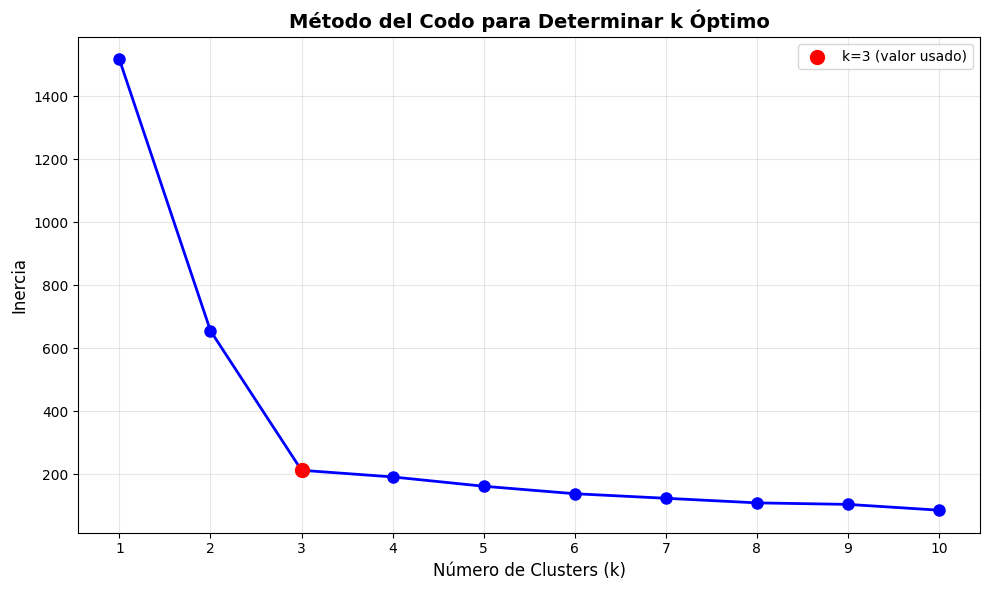


Análisis del método del codo:
La inercia disminuye a medida que aumenta k.
El punto donde la curva se 'dobla' (codo) sugiere el k óptimo.
En este caso, k=3 parece una elección razonable.

PROGRAMA COMPLETADO EXITOSAMENTE


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans

# ============================================
# PASO 1: GENERAR DATOS SINTÉTICOS
# ============================================
print("=" * 60)
print("PASO 1: Generando datos sintéticos")
print("=" * 60)

# Crear datos sintéticos con 3 centros/clusters
X, y_true = make_blobs(
    n_samples=300,      # 300 puntos de datos
    centers=3,          # 3 clusters/grupos
    cluster_std=0.60,   # Desviación estándar de los clusters
    random_state=0      # Semilla para reproducibilidad
)

print(f"Datos generados: {X.shape[0]} muestras con {X.shape[1]} características")
print(f"Centros reales de los datos: {np.unique(y_true).shape[0]} clusters")
print()

# ============================================
# PASO 2: VISUALIZAR LOS DATOS ORIGINALES
# ============================================
print("=" * 60)
print("PASO 2: Visualizando datos originales")
print("=" * 60)

plt.figure(figsize=(14, 6))

# Subplot 1: Datos originales sin agrupar
plt.subplot(1, 2, 1)
plt.scatter(X[:, 0], X[:, 1], s=50, alpha=0.7, edgecolors='k')
plt.title("Datos Sintéticos Originales", fontsize=14, fontweight='bold')
plt.xlabel("Característica 1", fontsize=12)
plt.ylabel("Característica 2", fontsize=12)
plt.grid(True, alpha=0.3)

# Subplot 2: Datos con clusters reales (solo para comparación)
plt.subplot(1, 2, 2)
plt.scatter(X[:, 0], X[:, 1], c=y_true, s=50, cmap='tab10', alpha=0.7, edgecolors='k')
plt.title("Datos con Clusters Reales", fontsize=14, fontweight='bold')
plt.xlabel("Característica 1", fontsize=12)
plt.ylabel("Característica 2", fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================
# PASO 3: APLICAR ALGORITMO K-MEANS
# ============================================
print("=" * 60)
print("PASO 3: Aplicando algoritmo K-Means")
print("=" * 60)

# Crear el modelo K-Means con 3 clusters
kmeans = KMeans(
    n_clusters=3,      # Número de clusters
    init='k-means++',  # Método de inicialización inteligente
    n_init=10,         # Número de inicializaciones diferentes
    max_iter=300,      # Máximo número de iteraciones
    random_state=0     # Semilla para reproducibilidad
)

# Ajustar el modelo a los datos
kmeans.fit(X)
print("Modelo K-Means entrenado exitosamente")
print(f"Número de iteraciones realizadas: {kmeans.n_iter_}")

# Obtener las etiquetas de los clusters
y_kmeans = kmeans.predict(X)

# Obtener los centros de los clusters
centers = kmeans.cluster_centers_

print(f"Centros de los clusters encontrados:")
for i, center in enumerate(centers):
    print(f"  Cluster {i}: [{center[0]:.2f}, {center[1]:.2f}]")
print()

# ============================================
# PASO 4: VISUALIZAR LOS RESULTADOS
# ============================================
print("=" * 60)
print("PASO 4: Visualizando resultados")
print("=" * 60)

plt.figure(figsize=(14, 6))

# Subplot 1: Clusters obtenidos con K-Means
plt.subplot(1, 2, 1)
scatter = plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=50,
                      cmap='viridis', alpha=0.7, edgecolors='k')
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200,
            alpha=0.75, marker='X', edgecolors='black', linewidth=2)

plt.title("Clusters Obtenidos con K-Means", fontsize=14, fontweight='bold')
plt.xlabel("Característica 1", fontsize=12)
plt.ylabel("Característica 2", fontsize=12)
plt.grid(True, alpha=0.3)

# Agregar leyenda para los centros
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], marker='X', color='w',
                          markerfacecolor='red', markersize=10,
                          markeredgecolor='black', label='Centroides')]
plt.legend(handles=legend_elements, loc='upper right')

# Subplot 2: Comparación entre clusters reales y predicción
plt.subplot(1, 2, 2)
colors = ['blue', 'green', 'orange', 'purple', 'brown', 'pink']

# Dibujar cada cluster con su color
for i in range(3):
    # Puntos del cluster real
    plt.scatter(X[y_true == i, 0], X[y_true == i, 1],
                s=30, alpha=0.5, color=colors[i],
                edgecolors='k', linewidth=0.5, label=f'Cluster real {i}')

    # Puntos del cluster predicho
    plt.scatter(X[y_kmeans == i, 0], X[y_kmeans == i, 1],
                s=50, alpha=0.7, color=colors[i],
                edgecolors='black', linewidth=1.5, marker='o',
                label=f'Cluster predicho {i}')

plt.title("Comparación: Clusters Reales vs. Predichos",
          fontsize=14, fontweight='bold')
plt.xlabel("Característica 1", fontsize=12)
plt.ylabel("Característica 2", fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# ============================================
# PASO 5: ANÁLISIS DE RESULTADOS
# ============================================
print("=" * 60)
print("PASO 5: Análisis de resultados")
print("=" * 60)

# Calcular algunas métricas básicas
from sklearn.metrics import silhouette_score, adjusted_rand_score

# Calcular coeficiente de silueta
silhouette_avg = silhouette_score(X, y_kmeans)

# Calcular índice Rand ajustado (comparación con etiquetas reales)
ari_score = adjusted_rand_score(y_true, y_kmeans)

print(f"Métricas de evaluación:")
print(f"  - Coeficiente de silueta: {silhouette_avg:.4f}")
print(f"     (Valor cercano a 1 indica buenos clusters)")
print(f"  - Índice Rand ajustado: {ari_score:.4f}")
print(f"     (Valor cercano a 1 indica buena concordancia con clusters reales)")
print()

# Mostrar distribución de puntos por cluster
print("Distribución de puntos por cluster:")
unique, counts = np.unique(y_kmeans, return_counts=True)
for cluster, count in zip(unique, counts):
    print(f"  Cluster {cluster}: {count} puntos ({count/len(y_kmeans)*100:.1f}%)")

# ============================================
# PASO 6: DETERMINAR EL NÚMERO ÓPTIMO DE CLUSTERS
# ============================================
print("\n" + "=" * 60)
print("PASO 6: Determinando número óptimo de clusters")
print("=" * 60)

# Método del codo (Elbow Method)
print("Calculando método del codo para diferentes valores de k...")

inertia = []
k_range = range(1, 11)

for k in k_range:
    kmeans_test = KMeans(n_clusters=k, random_state=0)
    kmeans_test.fit(X)
    inertia.append(kmeans_test.inertia_)

# Graficar el método del codo
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inercia', fontsize=12)
plt.title('Método del Codo para Determinar k Óptimo',
          fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Resaltar el punto k=3
plt.scatter(3, inertia[2], color='red', s=100, zorder=5,
            label='k=3 (valor usado)')
plt.legend()

plt.tight_layout()
plt.show()

print("\nAnálisis del método del codo:")
print("La inercia disminuye a medida que aumenta k.")
print("El punto donde la curva se 'dobla' (codo) sugiere el k óptimo.")
print(f"En este caso, k=3 parece una elección razonable.")

print("\n" + "=" * 60)
print("PROGRAMA COMPLETADO EXITOSAMENTE")
print("=" * 60)